In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
diamonds = sns.load_dataset('diamonds')

In [2]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [3]:
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


# pivot tables by hand

In [4]:
diamonds.groupby('cut')[['price']].mean()

,price
cut,
Ideal,3457.541970
Premium,4584.257704
Very Good,3981.759891
Good,3928.864452
Fair,4358.757764


In [5]:
diamonds.groupby(['cut', 'color'])[['price']].mean().unstack()

price                                                      \
color                D            E            F            G            H   
cut                                                                          
Ideal      2629.094566  2597.550090  3374.939362  3720.706388  3889.334831   
Premium    3631.292576  3538.914420  4324.890176  4500.742134  5216.706780   
Very Good  3470.467284  3214.652083  3778.820240  3872.753806  4535.390351   
Good       3405.382175  3423.644159  3495.750275  4123.482204  4276.254986   
Fair       4291.061350  3682.312500  3827.003205  4239.254777  5135.683168   

                                     
color                I            J  
cut                                  
Ideal      4451.970377  4918.186384  
Premium    5946.180672  6294.591584  
Very Good  5255.879568  5103.513274  
Good       5078.532567  4574.172638  
Fair       4685.445714  4975.655462

# pivot table syntax

In [6]:
diamonds.pivot_table('price', index='cut', columns='color')

color,D,E,F,G,H,I,J
cut,,,,,,,
Ideal,2629.094566,2597.550090,3374.939362,3720.706388,3889.334831,4451.970377,4918.186384
Premium,3631.292576,3538.914420,4324.890176,4500.742134,5216.706780,5946.180672,6294.591584
Very Good,3470.467284,3214.652083,3778.820240,3872.753806,4535.390351,5255.879568,5103.513274
Good,3405.382175,3423.644159,3495.750275,4123.482204,4276.254986,5078.532567,4574.172638
Fair,4291.061350,3682.312500,3827.003205,4239.254777,5135.683168,4685.445714,4975.655462


## multi-level pivot tables

In [7]:
cut_price = pd.cut(diamonds['price'], range(0, 6000, 2000))
cut_carat = pd.qcut(diamonds['carat'], 3)
diamonds.pivot_table('price', ['cut', cut_price], cut_carat, aggfunc='count').fillna(0)

carat                   (0.199, 0.5]  (0.5, 1.0]  (1.0, 5.01]
cut       price                                              
Ideal     (0, 2000]           9083.0      2519.0          0.0
          (2000, 4000]          68.0      3525.0        162.0
Premium   (0, 2000]           4303.0      1095.0          0.0
          (2000, 4000]          12.0      1952.0        317.0
Very Good (0, 2000]           3857.0      1126.0          0.0
          (2000, 4000]          32.0      2338.0        161.0
Good      (0, 2000]           1374.0       462.0          0.0
          (2000, 4000]          10.0      1042.0        144.0
Fair      (0, 2000]            189.0       198.0          1.0
          (2000, 4000]           4.0       457.0        130.0

## Plotting pivot tables

color                D            E            F            G            H  \
cut                                                                          
Ideal      3806.532106  3683.171591  4097.519455  4163.998740  3846.065529   
Premium    4111.564944  3987.881020  4357.804505  4320.505678  4278.491444   
Very Good  4072.806966  3821.529542  4142.189229  4054.557186  4034.242970   
Good       3845.999088  3806.246564  3820.558283  4087.365110  3825.520677   
Fair       4244.564841  3820.459862  3788.023975  3699.339188  3831.508566   

color                I            J  
cut                                  
Ideal      3808.070973  3733.765935  
Premium    4267.221626  4140.517668  
Very Good  4111.274074  3792.497711  
Good       3907.219571  3524.266237  
Fair       3514.653106  3345.942813  


<Axes: title={'center': 'Price per Carat by Cut and Color'}, xlabel='Cut', ylabel='Price per Carat'>

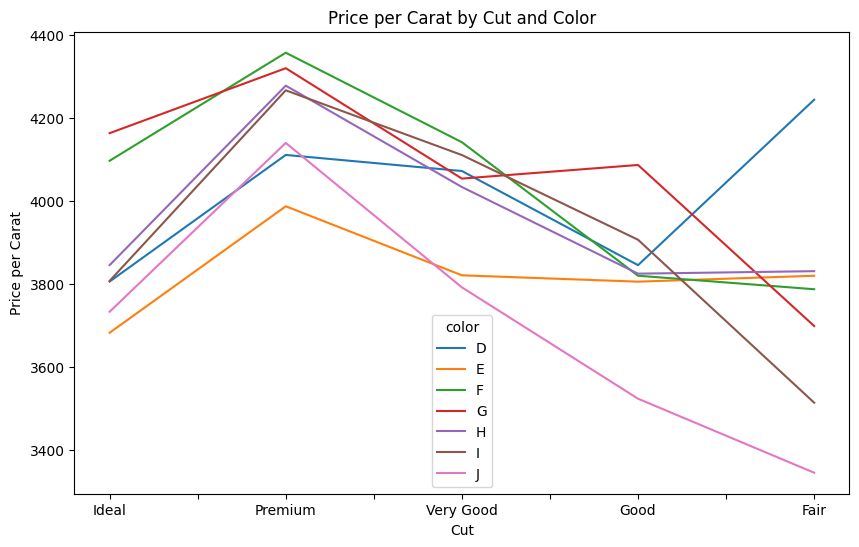

In [16]:
diamonds['price_per_carat'] = diamonds['price'] / diamonds['carat']
pivot = diamonds.pivot_table('price_per_carat', index='cut', columns='color')
print(pivot)
pivot.plot(figsize=(10, 6), title='Price per Carat by Cut and Color', ylabel='Price per Carat', xlabel='Cut')